In [5]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline     
sns.set(color_codes=True)
# pip install pandas openpyxl

Load in Data from CSV

In [6]:
df = pd.read_csv("./inbound_cleared.csv")
# To display the top 5 rows 
df.head(5)
df.tail(5)                        # To display the botton 5 rows

,indicator_code,indicator_label,indicator_previous_code,reporter_area_code,reporter_area_label,partner_area_code,partner_area_label,year,value,flag,flag_label,unit,notes
33834,INBD_TRIP_REGN_TOUR,inbound - trips - region - overnight visitors ...,CP_1_6_1_12,5353,St. Eustatius,70000,Other not classified (UNWTO total),2006,1.5,NaN,NaN,thousand trips,NaN
33835,INBD_TRIP_REGN_TOUR,inbound - trips - region - overnight visitors ...,CP_1_6_1_12,5353,St. Eustatius,70000,Other not classified (UNWTO total),2007,1.7,NaN,NaN,thousand trips,NaN
33836,INBD_TRIP_REGN_TOUR,inbound - trips - region - overnight visitors ...,CP_1_6_1_12,5353,St. Eustatius,70000,Other not classified (UNWTO total),2008,1.8,NaN,NaN,thousand trips,NaN
33837,INBD_TRIP_REGN_TOUR,inbound - trips - region - overnight visitors ...,CP_1_6_1_12,5353,St. Eustatius,70000,Other not classified (UNWTO total),2009,1.8,NaN,NaN,thousand trips,NaN
33838,INBD_TRIP_REGN_TOUR,inbound - trips - region - overnight visitors ...,CP_1_6_1_12,5353,St. Eustatius,70000,Other not classified (UNWTO total),2010,1.5,NaN,NaN,thousand trips,NaN


Variable	Description
- indicator_code	Code that identifies the indicator.
- indicator_previous_code	Indicator code used in the previous versions of the database (e.g. in the former publications "Compendium" [CP] and "Yearbook " [YB]).
- reporter_area_code	Code that identifies the geographic area represented by the statistical focal point that reported the data.
- reporter_area_label	Name of the reporter area as per the United Nations standard for statistical use (M49). - these total the "WORLD"
- partner_area_code	Code that identifies the geographical area other than the reporter area that participates in the phenomenon described by the indicator (i.e. area of origin for inbound flows and area of destination for outbound flows).
- partner_area_label	Name of the partner area as per the United Nations standard for statistical use (M49).
- year	Year represented by the value of the indicator.
- value	Value of the indicator.
- - flag	Code providing information about the quality of a value or about unusual or missing values, as per SDMX code list for observation status (https://sdmx.org/sdmx_cdcl/).
- flag_label	Description of the flag code.
- unit	Unit of measurement that defines the scale or type of the value.
- notes	Additional comments (if any)

Check the types of data, Column uniques, nulls

In [7]:
print(df.dtypes)
print(df.columns.tolist())
# print(df['reporter_area_label'].unique())



indicator_code                 str
indicator_label                str
indicator_previous_code        str
reporter_area_code           int64
reporter_area_label            str
partner_area_code            int64
partner_area_label             str
year                         int64
value                      float64
flag                           str
flag_label                     str
unit                           str
notes                          str
dtype: object
['indicator_code', 'indicator_label', 'indicator_previous_code', 'reporter_area_code', 'reporter_area_label', 'partner_area_code', 'partner_area_label', 'year', 'value', 'flag', 'flag_label', 'unit', 'notes']


Remove un-needed columns, filters and renaming

In [8]:
# Select only a few columns
new_df = df[['indicator_code','partner_area_code', 'reporter_area_code' ,'partner_area_label', 'reporter_area_label', 'year', 'value']]
# print(new_df.dtypes)
# print(new_df.head)
# print('_'*70)
# print(new_df.tail)
print(df['partner_area_label'].unique())
# print(df['reporter_area_label'].unique())
# Filter for USA only and non-total
filtered_df = new_df[
    (new_df['reporter_area_code'] == 840) ] 
filtered_df = filtered_df[
    (filtered_df['partner_area_code'] != 999) ] 

print('~'*70)
print(filtered_df['partner_area_code'].unique())




# print(filtered_df[filtered_df['year'] == 1999])
# Apply transformation to the value column
filtered_df['value'] = filtered_df['value'] * 1000

print(filtered_df.head())
# print(f"Shape: {filtered_df.shape}")

<ArrowStringArray>
[                                  'World',
                    'Africa (UNWTO total)',
                  'Americas (UNWTO total)',
 'East Asia and the Pacific (UNWTO total)',
                    'Europe (UNWTO total)',
               'Middle East (UNWTO total)',
      'Other not classified (UNWTO total)',
                'South Asia (UNWTO total)']
Length: 8, dtype: str
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
[10000 20000 30000 40000 50000 70000 60000]
            indicator_code  partner_area_code  reporter_area_code  \
32553  INBD_TRIP_REGN_TOUR              10000                 840   
32554  INBD_TRIP_REGN_TOUR              10000                 840   
32555  INBD_TRIP_REGN_TOUR              10000                 840   
32556  INBD_TRIP_REGN_TOUR              10000                 840   
32557  INBD_TRIP_REGN_TOUR              10000                 840   

         partner_area_label       reporter_area_label  year     value  
32553

EDA Just on the USA filtered Data

In [9]:
#Check the shape of filtered data
print(f"Shape of filtered data: {filtered_df.shape}")

# Count records per year (corrected)
print("\nRecords per year:")
print(filtered_df['year'].value_counts().sort_index())



Shape of filtered data: (200, 7)

Records per year:
year
1995    7
1996    7
1997    7
1998    7
1999    6
2000    7
2001    7
2002    7
2003    7
2004    7
2005    7
2006    7
2007    7
2008    7
2009    7
2010    7
2011    6
2012    6
2013    6
2014    6
2015    6
2016    6
2017    6
2018    6
2019    6
2020    7
2021    7
2022    7
2023    7
2024    7
Name: count, dtype: int64


Basic Bar chart

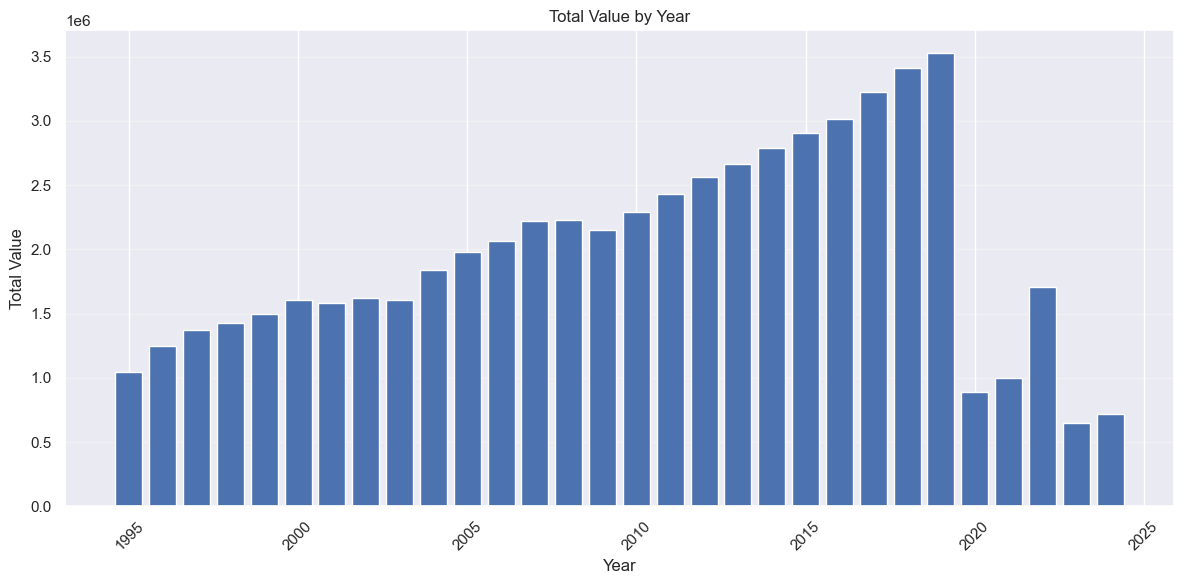

In [10]:

# Group by year and sum the values
yearly_data = new_df.groupby('year')['value'].sum().reset_index()

# Create bar chart
plt.figure(figsize=(12, 6))
plt.bar(yearly_data['year'], yearly_data['value'])
plt.title('Total Value by Year')
plt.xlabel('Year')
plt.ylabel('Total Value')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

% change year over year

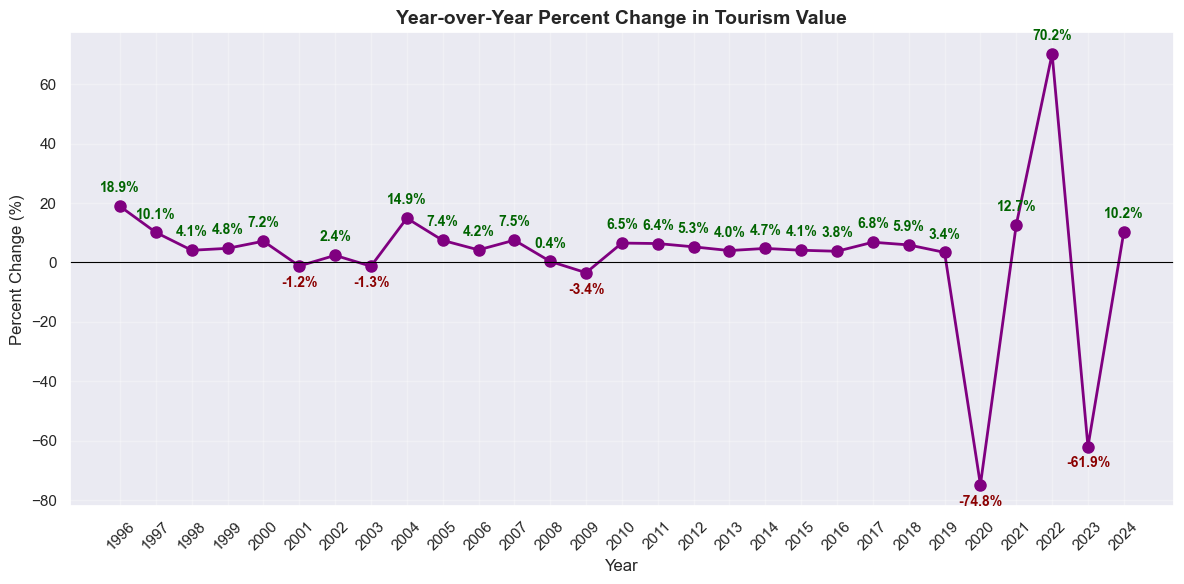

In [11]:
# Calculate percent change
yearly_data = new_df.groupby('year')['value'].sum().reset_index()
yearly_data = yearly_data.sort_values('year')
yearly_data['pct_change'] = yearly_data['value'].pct_change() * 100

# Create just the percent change line chart
plt.figure(figsize=(12, 6))
plt.plot(yearly_data['year'][1:], yearly_data['pct_change'][1:], 
         marker='o', linewidth=2, markersize=8, color='purple')

# Add horizontal line at 0
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Add value labels
for i, row in yearly_data.iloc[1:].iterrows():
    plt.annotate(f"{row['pct_change']:.1f}%", 
                (row['year'], row['pct_change']),
                textcoords="offset points", 
                xytext=(0, 10 if row['pct_change'] > 0 else -15),
                ha='center',
                fontsize=10,
                fontweight='bold',
                color='darkgreen' if row['pct_change'] > 0 else 'darkred')

plt.title('Year-over-Year Percent Change in Tourism Value', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percent Change (%)', fontsize=12)
plt.xticks(yearly_data['year'][1:], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Optional: Save new dataframe with year-over-year percent changes 
yearly_data = yearly_data.rename(
    columns={'value': 'tourism_value', 'pct_change': 'tourism_pct_change'})

yearly_data.to_csv('./features_inbound_cleaned.csv', index=False)

print("File saved successfully!")


File saved successfully!
